# Case 3 — IMDB visualization
Choose a question after inspecting the table schema and data quality. Document why the chart fits that question.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import inspect, text
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.database import create_database_engine

In [2]:
engine = create_database_engine()
inspector = inspect(engine)
display(inspector.get_columns('IMDB_movies'))

[{'name': 'Id',
  'type': INTEGER(),
  'default': None,
  'comment': None,
  'nullable': False,
  'autoincrement': False},
 {'name': 'Title',
  'type': VARCHAR(length=255),
  'default': None,
  'comment': None,
  'nullable': True},
 {'name': 'Genre',
  'type': VARCHAR(length=255),
  'default': None,
  'comment': None,
  'nullable': True},
 {'name': 'Director',
  'type': VARCHAR(length=255),
  'default': None,
  'comment': None,
  'nullable': True},
 {'name': 'Actors',
  'type': VARCHAR(length=255),
  'default': None,
  'comment': None,
  'nullable': True},
 {'name': 'Year',
  'type': INTEGER(),
  'default': None,
  'comment': None,
  'nullable': True,
  'autoincrement': False},
 {'name': 'Runtime',
  'type': INTEGER(),
  'default': None,
  'comment': None,
  'nullable': True,
  'autoincrement': False},
 {'name': 'Rating',
  'type': DECIMAL(precision=10, scale=0),
  'default': None,
  'comment': None,
  'nullable': True},
 {'name': 'Votes',
  'type': INTEGER(),
  'default': None,
  'com

## Exploração de qualidade dos dados

1000 filmes, sem `Id` duplicado. `Title`, `Genre`, `Director`, `Actors`, `Year`, `Runtime` e `Rating` estão 100% preenchidos; `RevenueMillions` e `Metascore` têm valores nulos, mas nenhuma das duas entra na análise escolhida. Vale notar que `Rating` está tipado como `DECIMAL(10,0)` no banco — ou seja, as notas já vêm arredondadas para inteiro (ex.: 8, não 8.1) —, o que limita a precisão da média por gênero calculada a seguir; isso é uma característica dos dados de origem, não um problema introduzido pela análise.

In [3]:
with engine.connect() as connection:
    total = connection.execute(text('SELECT COUNT(*) FROM IMDB_movies')).scalar()
    dup_ids = connection.execute(text(
        'SELECT COUNT(*) FROM (SELECT Id FROM IMDB_movies GROUP BY Id HAVING COUNT(*) > 1) t'
    )).scalar()
    print(f"Total de filmes: {total} | Ids duplicados: {dup_ids}")

    null_counts = {}
    for col in ['Title', 'Genre', 'Director', 'Actors', 'Year', 'Runtime', 'Rating', 'Votes', 'RevenueMillions', 'Metascore']:
        null_counts[col] = connection.execute(text(f'SELECT COUNT(*) FROM IMDB_movies WHERE {col} IS NULL')).scalar()
print('Valores nulos por coluna:', null_counts)

Total de filmes: 1000 | Ids duplicados: 0
Valores nulos por coluna: {'Title': 0, 'Genre': 0, 'Director': 0, 'Actors': 0, 'Year': 0, 'Runtime': 0, 'Rating': 0, 'Votes': 0, 'RevenueMillions': 128, 'Metascore': 64}


## Pergunta escolhida

**Qual gênero tem a melhor avaliação média no IMDB, entre os gêneros com representação suficiente na base (≥30 filmes)?**

Escolhida porque `Genre` e `Rating` estão 100% preenchidos (não exige nenhuma decisão de imputação) e porque comparar gêneros é uma pergunta de negócio direta (que tipo de filme performa melhor em avaliação). `Genre` é multi-rótulo (um filme pode ser `"Action,Adventure,Sci-Fi"` ao mesmo tempo), então cada filme é contado em todos os gêneros aos quais pertence. O limite mínimo de 30 filmes evita que gêneros raros (às vezes com 1 ou 2 filmes) distorçam o ranking com médias de amostra muito pequena.

1000 filmes -> 20 rótulos de gênero distintos após explodir
Gêneros com menos de 30 filmes (excluídos por amostra pequena): 6 de 20


,Genre,Filmes,Avaliacao_media
0,Biography,81,7.36
1,Animation,49,7.35
2,Drama,513,7.01
3,Mystery,106,6.94
4,Adventure,259,6.84
5,Crime,150,6.83
6,Sci-Fi,120,6.78
7,Family,51,6.75
8,Romance,141,6.72
9,Comedy,279,6.70


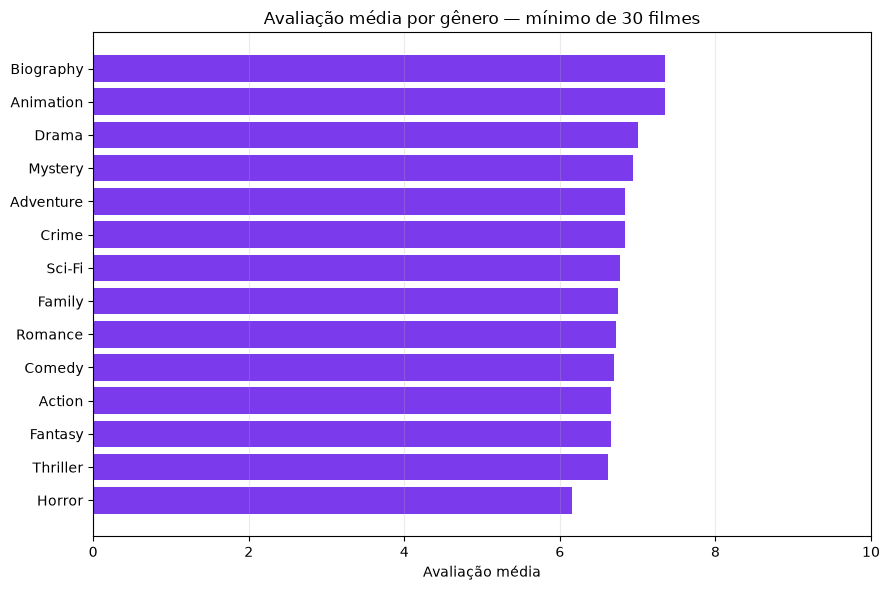

In [4]:
MIN_MOVIES = 30

movies = pd.read_sql_query(
    text("SELECT Id, Genre, Rating FROM IMDB_movies WHERE Genre IS NOT NULL AND Rating IS NOT NULL"),
    engine,
)
movies['Rating'] = pd.to_numeric(movies['Rating'])

# Genre é multi-rótulo (ex.: "Action,Adventure,Sci-Fi"): cada filme conta para todos os gêneros que tem
exploded = movies.assign(Genre=movies['Genre'].str.split(',')).explode('Genre')
exploded['Genre'] = exploded['Genre'].str.strip()
print(f"{movies['Id'].nunique()} filmes -> {exploded['Genre'].nunique()} rótulos de gênero distintos após explodir")

summary = (
    exploded.groupby('Genre', as_index=False)
    .agg(Filmes=('Id', 'nunique'), Avaliacao_media=('Rating', 'mean'))
    .sort_values('Avaliacao_media', ascending=False)
    .reset_index(drop=True)
)
print(f"Gêneros com menos de {MIN_MOVIES} filmes (excluídos por amostra pequena): {(summary['Filmes'] < MIN_MOVIES).sum()} de {len(summary)}")

summary_filtered = summary.query('Filmes >= @MIN_MOVIES').reset_index(drop=True)

TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
summary_filtered.to_csv(TABLE_DIR / 'case_03_rating_by_genre.csv', index=False, float_format='%.2f')

display(summary_filtered.round(2))

plot_data = summary_filtered.sort_values('Avaliacao_media')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_data['Genre'], plot_data['Avaliacao_media'], color='#7C3AED')
ax.set(
    title=f'Avaliação média por gênero — mínimo de {MIN_MOVIES} filmes',
    xlabel='Avaliação média',
    ylabel='',
    xlim=(0, 10),
)
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()

CHART_DIR = PROJECT_ROOT / 'outputs' / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(CHART_DIR / 'case_03_rating_by_genre.png', dpi=180, bbox_inches='tight')
plt.show()

## Interpretação

O gráfico de barras horizontais foi escolhido porque a pergunta é comparativa entre categorias (gêneros) — barras horizontais deixam os rótulos de texto (nomes dos gêneros) legíveis sem rotacionar texto, e a ordenação por valor deixa o ranking óbvio à primeira vista.

- **Biography** (7.36) e **Animation** (7.35) lideram a avaliação média, seguidos por **Drama** (7.01) — únicos três acima de 7.
- **Horror** (6.15) é o gênero com pior avaliação média entre os que têm representação suficiente, seguido por **Thriller** (6.62) e **Fantasy** (6.65).
- A diferença entre o topo e a base do ranking é de pouco mais de 1.2 pontos (numa escala de 0 a 10) — relevante, mas não um abismo: a maioria dos gêneros populares (Drama, Adventure, Crime, Sci-Fi, Comedy, Action) fica concentrada entre 6.6 e 7.0.
- Como a nota já vem arredondada para inteiro no banco (`DECIMAL(10,0)`), a média por gênero tem uma granularidade um pouco mais grosseira do que se tivéssemos a nota original do IMDB com uma casa decimal — isso não muda o ranking, mas é uma limitação de precisão a declarar.